# Phase 4d — Noise-Augmented Training

**Goal:** Test whether adding controlled noise during training improves robustness to noisy respiratory sounds.

The existing **AST + Focal Loss + SpecAugment + Mixup** training recipe is retained. Additional Gaussian noise is injected into a fraction of training samples at randomized SNR levels.

The trained model is then evaluated using the **same SNR sweep as Phase 4b**, with the same test cycles, noise levels, and evaluation procedure, allowing a direct **before-vs-after mitigation** comparison.

### Inputs

* `03a-ast-finetuning-ce` — cached waveforms
* `01-data-preparation` — train/validation/test splits
* `04b-noise-robustness-sweep` — baseline `noise_sweep_results.csv`

In [1]:
import random
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.signal import butter, sosfiltfilt
import librosa

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

from transformers import ASTFeatureExtractor, ASTForAudioClassification, get_linear_schedule_with_warmup

from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

plt.rcParams["figure.dpi"] = 110

## **1. Config**

In [2]:
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

PHASE1_DIR = Path(
    "/kaggle/input/notebooks/praveshsubba/01-data-preparation/icbhi_processed"
)
SPLIT_DIR = PHASE1_DIR / "splits"

CE_NOTEBOOK_DIR = Path(
    "/kaggle/input/notebooks/praveshsubba/03a-ast-finetuning-ce"
)
WAVEFORM_CACHE_DIR = CE_NOTEBOOK_DIR / "waveform_cache"

NOISE_SWEEP_NOTEBOOK_DIR = Path(
    "/kaggle/input/notebooks/praveshsubba/04b-noise-robustness-sweep"
)
BEFORE_SWEEP_CSV = NOISE_SWEEP_NOTEBOOK_DIR / "noise_sweep_results.csv"

CHECKPOINT_DIR = Path("/kaggle/working/checkpoints")
CHECKPOINT_DIR.mkdir(parents=True, exist_ok=True)
RESULTS_CSV = Path("/kaggle/working/results_phase4d.csv")

LABELS = ["normal", "crackle", "wheeze", "both"]

TARGET_SR = 16000
LOWCUT = 50
HIGHCUT = 8000
TARGET_DURATION = 8.0

AST_CHECKPOINT = "MIT/ast-finetuned-audioset-10-10-0.4593"

BATCH_SIZE = 8
NUM_WORKERS = 2
LEARNING_RATE = 1e-5
WEIGHT_DECAY = 0.01
WARMUP_RATIO = 0.1
MAX_EPOCHS = 15
EARLY_STOP_PATIENCE = 4
GRAD_CLIP_NORM = 1.0

FOCAL_GAMMA = 2.0
TIME_MASK_PARAM = 100
FREQ_MASK_PARAM = 20
N_TIME_MASKS = 2
N_FREQ_MASKS = 2
MIXUP_ALPHA = 0.4

# Noise-augmentation-specific config
NOISE_AUG_PROB = 0.5          # fraction of training batches that get noise injected
                                # (not all -- keeps some clean signal in training too)
NOISE_AUG_SNR_RANGE_DB = (0, 20)   # each noisy batch gets a random SNR sampled from this range

SNR_LEVELS_DB = [None, 20, 15, 10, 5, 0]   # must match 04b exactly, for a fair before/after comparison

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", DEVICE)
assert DEVICE.type == "cuda", "Enable the GPU accelerator for this notebook before continuing."

Device: cuda


## **2. Load splits + resolve cached waveforms**

In [3]:
train_df = pd.read_csv(SPLIT_DIR / "train.csv")
val_df   = pd.read_csv(SPLIT_DIR / "val.csv")
test_df  = pd.read_csv(SPLIT_DIR / "test.csv")

required_cols = {"audio_path", "start", "end", "label"}
missing = required_cols - set(train_df.columns)
assert not missing, f"Missing expected columns: {missing}"

print(train_df.shape, val_df.shape, test_df.shape)

(4580, 14) (1133, 14) (1185, 14)


In [4]:
from pathlib import Path

def resolve_waveform_path(row, cache_dir=WAVEFORM_CACHE_DIR):
    # Recreate the exact filename used during Phase 1
    cycle_id = f"{Path(row['audio_path']).stem}_{float(row['start'])}_{float(row['end'])}"
    
    waveform_path = cache_dir / f"{cycle_id}.npy"

    if not waveform_path.exists():
        raise FileNotFoundError(
            f"Waveform not found:\n{waveform_path}"
        )

    return str(waveform_path)


# Create waveform_path column for all splits
for name, df in [
    ("train", train_df),
    ("val", val_df),
    ("test", test_df)
]:
    df["waveform_path"] = [
        resolve_waveform_path(row)
        for _, row in df.iterrows()
    ]

    print(f"{name}: {len(df)} waveform paths created")

print("\nAll waveform paths resolved successfully.")


train: 4580 waveform paths created
val: 1133 waveform paths created
test: 1185 waveform paths created

All waveform paths resolved successfully.


## **3. Noise-augmented training Dataset**

Each training sample has a `NOISE_AUG_PROB` chance of getting noise injected at a random SNR before feature extraction. SpecAugment (on the resulting spectrogram) still applies on top, same as `03d` -- this stacks noise augmentation with the existing recipe rather than replacing it. Val/test datasets stay completely clean here; noisy evaluation happens separately in the sweep at the end, mirroring `04b`.

In [5]:
def add_noise_at_snr(signal, snr_db, rng):
    if snr_db is None:
        return signal
    signal_power = np.mean(signal.astype(np.float64) ** 2)
    noise = rng.standard_normal(len(signal))
    noise_power = np.mean(noise ** 2)
    target_noise_power = signal_power / (10 ** (snr_db / 10))
    scale = np.sqrt(target_noise_power / noise_power)
    return (signal + scale * noise).astype(np.float32)


def spec_augment(x, time_mask_param=TIME_MASK_PARAM, freq_mask_param=FREQ_MASK_PARAM,
                  n_time_masks=N_TIME_MASKS, n_freq_masks=N_FREQ_MASKS):
    x = x.clone()
    T, M = x.shape
    fill_value = x.mean()
    for _ in range(n_time_masks):
        t = np.random.randint(0, time_mask_param)
        t0 = np.random.randint(0, max(T - t, 1))
        x[t0:t0 + t, :] = fill_value
    for _ in range(n_freq_masks):
        f = np.random.randint(0, freq_mask_param)
        f0 = np.random.randint(0, max(M - f, 1))
        x[:, f0:f0 + f] = fill_value
    return x


def mixup_batch(x, y, alpha=MIXUP_ALPHA):
    batch_size = x.size(0)
    lam = np.random.beta(alpha, alpha) if alpha > 0 else 1.0
    perm = torch.randperm(batch_size, device=x.device)
    return lam * x + (1 - lam) * x[perm], y, y[perm], lam


class NoiseAugmentedASTDataset(Dataset):
    def __init__(self, df, feature_extractor, label_list=LABELS,
                 use_specaugment=False, use_noise_aug=False):
        self.df = df.reset_index(drop=True)
        self.fe = feature_extractor
        self.label2idx = {l: i for i, l in enumerate(label_list)}
        self.use_specaugment = use_specaugment
        self.use_noise_aug = use_noise_aug

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        waveform = np.load(row["waveform_path"])

        if self.use_noise_aug and np.random.random() < NOISE_AUG_PROB:
            snr_db = np.random.uniform(*NOISE_AUG_SNR_RANGE_DB)
            rng = np.random.default_rng()
            waveform = add_noise_at_snr(waveform, snr_db, rng)

        x = self.fe(waveform, sampling_rate=TARGET_SR, return_tensors="pt")["input_values"].squeeze(0)
        if self.use_specaugment:
            x = spec_augment(x)

        y = torch.tensor(self.label2idx[row["label"]], dtype=torch.long)
        return x, y

## **4. Focal Loss + ICBHI Score (identical to prior notebooks)**

In [6]:
class FocalLoss(nn.Module):
    def __init__(self, alpha=None, gamma=2.0, reduction="mean"):
        super().__init__()
        self.alpha, self.gamma, self.reduction = alpha, gamma, reduction

    def forward(self, logits, targets):
        ce_loss = F.cross_entropy(logits, targets, reduction="none")
        p_t = torch.exp(-ce_loss)
        loss = (1 - p_t) ** self.gamma * ce_loss
        if self.alpha is not None:
            loss = self.alpha[targets] * loss
        return loss.mean() if self.reduction == "mean" else (loss.sum() if self.reduction == "sum" else loss)


def icbhi_score(y_true_labels, y_pred_labels):
    y_true_abn = np.array([l != "normal" for l in y_true_labels])
    y_pred_abn = np.array([l != "normal" for l in y_pred_labels])
    normal_mask = ~y_true_abn
    specificity = (~y_pred_abn[normal_mask]).sum() / max(normal_mask.sum(), 1)
    abnormal_mask = y_true_abn
    sensitivity = y_pred_abn[abnormal_mask].sum() / max(abnormal_mask.sum(), 1)
    return {"sensitivity": sensitivity, "specificity": specificity, "icbhi_score": (sensitivity + specificity) / 2}


idx2label = {i: l for i, l in enumerate(LABELS)}
results_log = []

def log_result(model_name, split, scores, notes=""):
    results_log.append({
        "model": model_name, "split": split,
        "sensitivity": scores["sensitivity"], "specificity": scores["specificity"],
        "icbhi_score": scores["icbhi_score"], "notes": notes,
    })
    pd.DataFrame(results_log).to_csv(RESULTS_CSV, index=False)

## **5. Train with noise augmentation added**

In [7]:
feature_extractor = ASTFeatureExtractor.from_pretrained(AST_CHECKPOINT)

train_ds = NoiseAugmentedASTDataset(train_df, feature_extractor, use_specaugment=True, use_noise_aug=True)
val_ds   = NoiseAugmentedASTDataset(val_df,   feature_extractor, use_specaugment=False, use_noise_aug=False)
test_ds  = NoiseAugmentedASTDataset(test_df,  feature_extractor, use_specaugment=False, use_noise_aug=False)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,  num_workers=NUM_WORKERS)
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS)
test_loader  = DataLoader(test_ds,  batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS)

model = ASTForAudioClassification.from_pretrained(
    AST_CHECKPOINT, num_labels=len(LABELS),
    id2label={i: l for i, l in enumerate(LABELS)}, label2id={l: i for i, l in enumerate(LABELS)},
    ignore_mismatched_sizes=True,
).to(DEVICE)

class_counts = train_df["label"].value_counts().reindex(LABELS).fillna(0)
class_weights = (1.0 / class_counts).values
class_weights = class_weights / class_weights.sum() * len(LABELS)
class_weights = torch.tensor(class_weights, dtype=torch.float32).to(DEVICE)
criterion = FocalLoss(alpha=class_weights, gamma=FOCAL_GAMMA)

optimizer = torch.optim.AdamW(model.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)
total_steps = len(train_loader) * MAX_EPOCHS
warmup_steps = int(total_steps * WARMUP_RATIO)
scheduler = get_linear_schedule_with_warmup(optimizer, warmup_steps, total_steps)
scaler = torch.amp.GradScaler("cuda")

best_val_score = -1
epochs_without_improvement = 0
checkpoint_path = CHECKPOINT_DIR / "ast_noise_augmented_best.pt"

for epoch in range(1, MAX_EPOCHS + 1):
    model.train()
    for xb, yb in train_loader:
        xb, yb = xb.to(DEVICE), yb.to(DEVICE)
        optimizer.zero_grad()
        with torch.amp.autocast("cuda"):
            x_mixed, y_a, y_b, lam = mixup_batch(xb, yb)
            logits = model(input_values=x_mixed).logits
            loss = lam * criterion(logits, y_a) + (1 - lam) * criterion(logits, y_b)
        scaler.scale(loss).backward()
        scaler.unscale_(optimizer)
        torch.nn.utils.clip_grad_norm_(model.parameters(), GRAD_CLIP_NORM)
        scale_before = scaler.get_scale()
        scaler.step(optimizer)
        scaler.update()
        if scaler.get_scale() >= scale_before:
            scheduler.step()

    model.eval()
    all_true, all_pred = [], []
    with torch.no_grad():
        for xb, yb in val_loader:
            xb = xb.to(DEVICE)
            with torch.amp.autocast("cuda"):
                logits = model(input_values=xb).logits
            preds = logits.argmax(dim=1).cpu().numpy()
            all_true.extend(idx2label[i] for i in yb.numpy())
            all_pred.extend(idx2label[i] for i in preds)
    val_scores = icbhi_score(all_true, all_pred)

    print(f"Epoch {epoch:02d} | val_ICBHI_score={val_scores['icbhi_score']*100:.2f}%")

    if val_scores["icbhi_score"] > best_val_score:
        best_val_score = val_scores["icbhi_score"]
        epochs_without_improvement = 0
        torch.save(model.state_dict(), checkpoint_path)
        print("  -> new best")
    else:
        epochs_without_improvement += 1
    if epochs_without_improvement >= EARLY_STOP_PATIENCE:
        print(f"Early stopping at epoch {epoch}")
        break

model.load_state_dict(torch.load(checkpoint_path))
model.eval()

preprocessor_config.json:   0%|          | 0.00/297 [00:00<?, ?B/s]

config.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/346M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/203 [00:00<?, ?it/s]

ASTForAudioClassification LOAD REPORT from: MIT/ast-finetuned-audioset-10-10-0.4593
Key                     | Status   |                                                                                       
------------------------+----------+---------------------------------------------------------------------------------------
classifier.dense.weight | MISMATCH | Reinit due to size mismatch ckpt: torch.Size([527, 768]) vs model:torch.Size([4, 768])
classifier.dense.bias   | MISMATCH | Reinit due to size mismatch ckpt: torch.Size([527]) vs model:torch.Size([4])          

Notes:
- MISMATCH	:ckpt weights were loaded, but they did not match the original empty weight shapes.


Epoch 01 | val_ICBHI_score=65.64%
  -> new best
Epoch 02 | val_ICBHI_score=52.20%
Epoch 03 | val_ICBHI_score=69.83%
  -> new best
Epoch 04 | val_ICBHI_score=70.00%
  -> new best
Epoch 05 | val_ICBHI_score=67.18%
Epoch 06 | val_ICBHI_score=61.17%
Epoch 07 | val_ICBHI_score=64.66%
Epoch 08 | val_ICBHI_score=68.75%
Early stopping at epoch 8


ASTForAudioClassification(
  (audio_spectrogram_transformer): ASTModel(
    (embeddings): ASTEmbeddings(
      (patch_embeddings): ASTPatchEmbeddings(
        (projection): Conv2d(1, 768, kernel_size=(16, 16), stride=(10, 10))
      )
      (dropout): Dropout(p=0.0, inplace=False)
    )
    (encoder): ASTEncoder(
      (layer): ModuleList(
        (0-11): 12 x ASTLayer(
          (attention): ASTAttention(
            (attention): ASTSelfAttention(
              (query): Linear(in_features=768, out_features=768, bias=True)
              (key): Linear(in_features=768, out_features=768, bias=True)
              (value): Linear(in_features=768, out_features=768, bias=True)
            )
            (output): ASTSelfOutput(
              (dense): Linear(in_features=768, out_features=768, bias=True)
              (dropout): Dropout(p=0.0, inplace=False)
            )
          )
          (intermediate): ASTIntermediate(
            (dense): Linear(in_features=768, out_features=3072, bias=T

## **6. Clean-condition evaluation (val, then test once) — sanity check before the sweep**

In [8]:
def predict_all(loader):
    all_true, all_pred = [], []
    with torch.no_grad():
        for xb, yb in loader:
            xb = xb.to(DEVICE)
            with torch.amp.autocast("cuda"):
                logits = model(input_values=xb).logits
            preds = logits.argmax(dim=1).cpu().numpy()
            all_true.extend(idx2label[i] for i in yb.numpy())
            all_pred.extend(idx2label[i] for i in preds)
    return all_true, all_pred


val_true, val_pred = predict_all(val_loader)
val_scores = icbhi_score(val_true, val_pred)
print(f"Val (clean): ICBHI Score = {val_scores['icbhi_score']*100:.2f}%")
log_result("AST + Focal + SpecAug + Mixup + NoiseAug", "val", val_scores)

test_true, test_pred = predict_all(test_loader)
test_scores = icbhi_score(test_true, test_pred)
print(f"Test (clean): ICBHI Score = {test_scores['icbhi_score']*100:.2f}%")
print(f"(compare against Phase 3 winner's clean test score: 67.22% -- some clean-condition "
      f"trade-off is expected and acceptable if the noisy-condition scores below improve enough to justify it)")
log_result("AST + Focal + SpecAug + Mixup + NoiseAug", "test", test_scores)

Val (clean): ICBHI Score = 70.00%
Test (clean): ICBHI Score = 66.15%
(compare against Phase 3 winner's clean test score: 67.22% -- some clean-condition trade-off is expected and acceptable if the noisy-condition scores below improve enough to justify it)


## **7. Re-run the exact same noise sweep from `04b`**

Same SNR levels, same test cycles, same noise-generation logic (seeded identically per cycle+SNR combination) -- the only difference from `04b` is which model is being evaluated. This is what makes the before/after comparison fair.

In [9]:
class NoisyEvalDataset(Dataset):
    def __init__(self, df, feature_extractor, snr_db, label_list=LABELS):
        self.df = df.reset_index(drop=True)
        self.fe = feature_extractor
        self.snr_db = snr_db
        self.label2idx = {l: i for i, l in enumerate(label_list)}

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        waveform = np.load(row["waveform_path"])
        rng = np.random.default_rng(hash((row["waveform_path"], self.snr_db)) % (2**32))
        noisy_waveform = add_noise_at_snr(waveform, self.snr_db, rng)
        x = self.fe(noisy_waveform, sampling_rate=TARGET_SR, return_tensors="pt")["input_values"].squeeze(0)
        y = torch.tensor(self.label2idx[row["label"]], dtype=torch.long)
        return x, y


after_sweep_results = []
for snr_db in SNR_LEVELS_DB:
    label = "clean" if snr_db is None else f"{snr_db}dB"
    ds = NoisyEvalDataset(test_df, feature_extractor, snr_db=snr_db)
    loader = DataLoader(ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS)

    all_true, all_pred = [], []
    with torch.no_grad():
        for xb, yb in loader:
            xb = xb.to(DEVICE)
            with torch.amp.autocast("cuda"):
                logits = model(input_values=xb).logits
            preds = logits.argmax(dim=1).cpu().numpy()
            all_true.extend(idx2label[i] for i in yb.numpy())
            all_pred.extend(idx2label[i] for i in preds)

    scores = icbhi_score(all_true, all_pred)
    print(f"SNR={label:6s} | ICBHI Score={scores['icbhi_score']*100:5.2f}%")
    after_sweep_results.append({"snr_label": label, "snr_db": snr_db, **scores})
    log_result("AST + NoiseAug (after mitigation)", "test", scores, notes=f"SNR={label}")

after_df = pd.DataFrame(after_sweep_results)
after_df.to_csv("/kaggle/working/noise_sweep_after_mitigation.csv", index=False)
after_df

SNR=clean  | ICBHI Score=66.15%
SNR=20dB   | ICBHI Score=62.71%
SNR=15dB   | ICBHI Score=61.42%
SNR=10dB   | ICBHI Score=62.92%
SNR=5dB    | ICBHI Score=62.44%
SNR=0dB    | ICBHI Score=61.67%


,snr_label,snr_db,sensitivity,specificity,icbhi_score
0,clean,NaN,0.596639,0.726375,0.661507
1,20dB,20.0,0.640756,0.613540,0.627148
2,15dB,15.0,0.621849,0.606488,0.614168
3,10dB,10.0,0.653361,0.605078,0.629219
4,5dB,5.0,0.632353,0.616361,0.624357
5,0dB,0.0,0.611345,0.622003,0.616674


## **8. Before vs. after — the actual mitigation result**

This plot is the answer to your project's core research question: did the mitigation actually help, and by how much, at each noise level (not just on average).

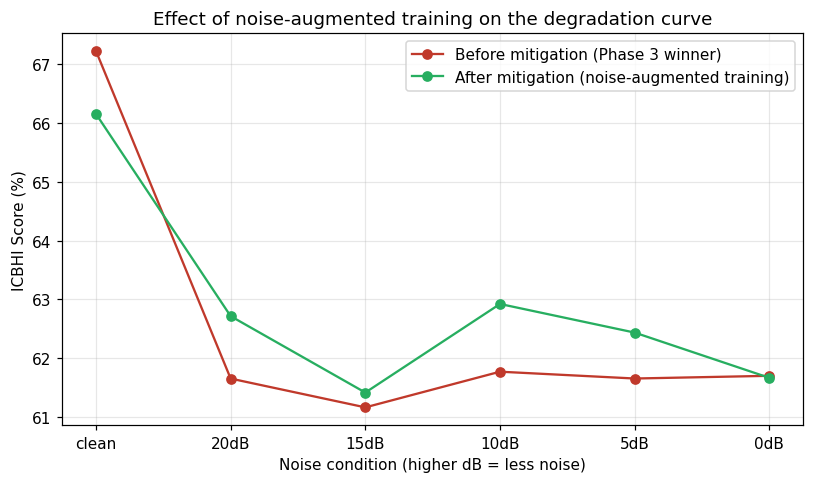

  snr_label  improvement_points
0     clean           -1.068643
1      20dB            1.060347
2      15dB            0.251567
3      10dB            1.150573
4       5dB            0.780185
5       0dB           -0.034076


In [10]:
before_df = pd.read_csv(BEFORE_SWEEP_CSV)   # from 04b, unmitigated model

fig, ax = plt.subplots(figsize=(7.5, 4.5))
ax.plot(before_df["snr_label"], before_df["icbhi_score"] * 100, marker="o",
        color="#C0392B", label="Before mitigation (Phase 3 winner)")
ax.plot(after_df["snr_label"], after_df["icbhi_score"] * 100, marker="o",
        color="#27AE60", label="After mitigation (noise-augmented training)")

ax.set_xlabel("Noise condition (higher dB = less noise)")
ax.set_ylabel("ICBHI Score (%)")
ax.set_title("Effect of noise-augmented training on the degradation curve")
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("/kaggle/working/mitigation_comparison.png", dpi=150)
plt.show()

merged = before_df.merge(after_df, on="snr_label", suffixes=("_before", "_after"))
merged["improvement_points"] = (merged["icbhi_score_after"] - merged["icbhi_score_before"]) * 100
print(merged[["snr_label", "improvement_points"]])

## **9. Deliverable checklist**

- Noise-augmented training added on top of the existing Focal + SpecAugment + Mixup recipe (not a replacement)
- Clean-condition performance checked before the sweep -- confirms the mitigation didn't badly break normal-condition accuracy in exchange for noise robustness
- Identical SNR sweep methodology to `04b`, same test cycles, same seeded noise -- fair before/after comparison

